## Setup

In [1]:
import os, glob, time, random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print("Device:", device, "| GPUs available:", n_gpus)
assert device.type == "cuda", "GPU not active! Go to Settings -> Accelerator -> GPU T4 x2, save, and rerun from here."

Device: cuda | GPUs available: 2


## Download dataset (direct URL, extract to /tmp so it doesn't eat Kaggle's output quota)

In [2]:
DATA_DIR = "/tmp/aalto_data"
os.makedirs(DATA_DIR, exist_ok=True)
zip_path = os.path.join(DATA_DIR, "Keystrokes.zip")

if not os.path.exists(zip_path):
    !wget -q --show-progress -O {zip_path} https://userinterfaces.aalto.fi/136Mkeystrokes/data/Keystrokes.zip

print("Zip size (MB):", round(os.path.getsize(zip_path)/1e6, 1))

/tmp/aalto_data/Key 100%[===================>]   1.46G  25.6MB/s    in 60s     
Zip size (MB): 1572.8


## Extract

In [3]:
extract_dir = os.path.join(DATA_DIR, "extracted")
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    t0 = time.time()
    !unzip -q {zip_path} -d {extract_dir}
    print("Unzip took", round(time.time()-t0, 1), "sec")

all_txt = glob.glob(os.path.join(extract_dir, "**", "*.txt"), recursive=True)
keystroke_files = [f for f in all_txt if "keystrokes" in os.path.basename(f).lower()]
print("Total keystroke files:", len(keystroke_files))

Unzip took 127.8 sec
Total keystroke files: 168593


## Detect columns

In [4]:
sample_df = pd.read_csv(keystroke_files[0], sep="\t", quoting=3)
cols = sample_df.columns
participant_col = [c for c in cols if "PARTICIPANT" in c.upper()][0]
section_col     = [c for c in cols if "TEST_SECTION" in c.upper()][0]
press_col       = [c for c in cols if "PRESS_TIME" in c.upper()][0]
release_col     = [c for c in cols if "RELEASE_TIME" in c.upper()][0]
print(participant_col, section_col, press_col, release_col)

PARTICIPANT_ID TEST_SECTION_ID PRESS_TIME RELEASE_TIME


## Sequence builder (plain, 1 window per sentence — used for full-dataset / Siamese)

In [5]:
SEQ_LEN = 50
MIN_KEYS_PER_SECTION = 10

def file_to_sequences(fpath):
    try:
        df = pd.read_csv(fpath, sep="\t", usecols=[participant_col, section_col, press_col, release_col], quoting=3)
    except Exception:
        return [], []
    df[press_col] = pd.to_numeric(df[press_col], errors="coerce")
    df[release_col] = pd.to_numeric(df[release_col], errors="coerce")
    df = df.dropna(subset=[press_col, release_col])

    seqs, labels = [], []
    pid = os.path.basename(fpath).split("_")[0]
    for _, g in df.groupby(section_col):
        g = g.sort_values(press_col)
        if len(g) < MIN_KEYS_PER_SECTION:
            continue
        press = g[press_col].values.astype(np.float64)
        release = g[release_col].values.astype(np.float64)
        hold = release - press
        dd = np.diff(press, prepend=press[0]); dd[0] = 0
        ud = press[1:] - release[:-1]; ud = np.insert(ud, 0, 0)
        seq = np.stack([hold, dd, ud], axis=1)[:SEQ_LEN]
        if len(seq) < SEQ_LEN:
            seq = np.vstack([seq, np.zeros((SEQ_LEN - len(seq), 3))])
        seqs.append(seq.astype(np.float32))
        labels.append(pid)
    return seqs, labels

## Running full preprocessing (all 168k users, for Siamese)

In [6]:
import multiprocessing as mp

print("CPU cores available:", mp.cpu_count())

CPU cores available: 4


In [7]:
MAX_USERS = None
files_to_use = keystroke_files if MAX_USERS is None else keystroke_files[:MAX_USERS]

NUM_WORKERS = mp.cpu_count()  # Kaggle usually gives 4
print(f"Using {NUM_WORKERS} parallel workers")

t0 = time.time()
X_list, y_list = [], []

with mp.Pool(processes=NUM_WORKERS) as pool:
    for i, (seqs, labels) in enumerate(pool.imap(file_to_sequences, files_to_use, chunksize=50)):
        X_list.extend(seqs); y_list.extend(labels)
        if (i+1) % 8000 == 0:
            print(f"{i+1}/{len(files_to_use)} files | {len(X_list)} samples | {(time.time()-t0)/60:.1f} min elapsed")

X = np.array(X_list, dtype=np.float32)
y_raw = np.array(y_list)
print("Final shape:", X.shape, "| unique users:", len(set(y_raw)))

np.save("/kaggle/working/X_full.npy", X)
np.save("/kaggle/working/y_raw_full.npy", y_raw)

Using 4 parallel workers
8000/168593 files | 119070 samples | 0.5 min elapsed
16000/168593 files | 237960 samples | 0.9 min elapsed
24000/168593 files | 357015 samples | 1.3 min elapsed
32000/168593 files | 476025 samples | 1.7 min elapsed
40000/168593 files | 595140 samples | 2.1 min elapsed
48000/168593 files | 714120 samples | 2.5 min elapsed
56000/168593 files | 832980 samples | 3.0 min elapsed
64000/168593 files | 952005 samples | 3.4 min elapsed
72000/168593 files | 1070955 samples | 3.8 min elapsed
80000/168593 files | 1189965 samples | 4.2 min elapsed
88000/168593 files | 1308825 samples | 4.6 min elapsed
96000/168593 files | 1427655 samples | 5.0 min elapsed
104000/168593 files | 1546485 samples | 5.5 min elapsed
112000/168593 files | 1665525 samples | 5.9 min elapsed
120000/168593 files | 1784580 samples | 6.3 min elapsed
128000/168593 files | 1903380 samples | 6.7 min elapsed
136000/168593 files | 2022450 samples | 7.1 min elapsed
144000/168593 files | 2141715 samples | 7.5 

## EDA: thorough per-user sample distribution

Total users: 167147
Samples per user -> min: 15 | max: 15 | mean: 15.0 | median: 15.0
Percentiles (10/25/50/75/90): [15. 15. 15. 15. 15.]

Users with >=30 samples: 0
Users with >=50 samples: 0
Users with >=100 samples: 0


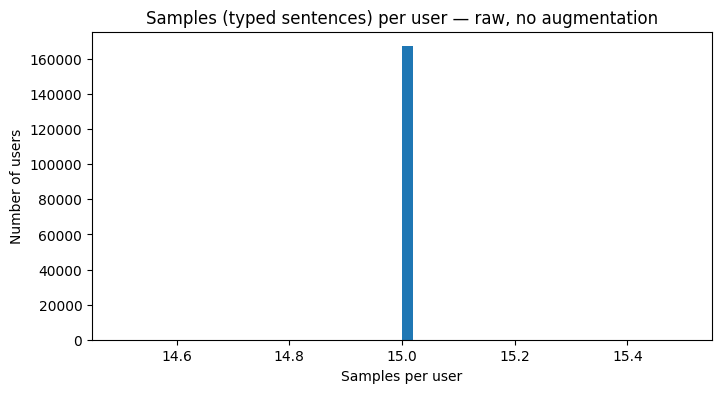

In [8]:
counts = Counter(y_raw)
vals = np.array(list(counts.values()))

print("Total users:", len(vals))
print("Samples per user -> min:", vals.min(), "| max:", vals.max(),
      "| mean:", round(vals.mean(),1), "| median:", np.median(vals))
print("Percentiles (10/25/50/75/90):", np.percentile(vals, [10,25,50,75,90]))
print("\nUsers with >=30 samples:", (vals>=30).sum())
print("Users with >=50 samples:", (vals>=50).sum())
print("Users with >=100 samples:", (vals>=100).sum())

plt.figure(figsize=(8,4))
plt.hist(vals, bins=50)
plt.title("Samples (typed sentences) per user — raw, no augmentation")
plt.xlabel("Samples per user"); plt.ylabel("Number of users")
plt.show()

## Full train/test split + scale (for Siamese / verification, uses ALL users)

In [9]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes_full = len(le.classes_)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler_full = StandardScaler()
scaler_full.fit(X_train_full.reshape(-1, 3))

def scale(x, scaler):
    shp = x.shape
    return scaler.transform(x.reshape(-1,3)).reshape(shp).astype(np.float32)

X_train_full = scale(X_train_full, scaler_full)
X_test_full  = scale(X_test_full, scaler_full)
print(X_train_full.shape, X_test_full.shape, "| num_classes_full:", num_classes_full)

(2005764, 50, 3) (501441, 50, 3) | num_classes_full: 167147


## Dataset class + Siamese dataloaders

In [10]:
class KeystrokeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE = 256 if n_gpus > 1 else 128

def make_pairs(X, y, n_pairs=10000):
    pairs_a, pairs_b, labels = [], [], []
    classes = np.unique(y)
    idx_by_class = {c: np.where(y==c)[0] for c in classes}
    for _ in range(n_pairs):
        c1 = np.random.choice(classes)
        if np.random.rand() < 0.5 and len(idx_by_class[c1]) > 1:
            i, j = np.random.choice(idx_by_class[c1], 2, replace=False)
            label = 1
        else:
            c2 = np.random.choice(classes[classes != c1])
            i = np.random.choice(idx_by_class[c1]); j = np.random.choice(idx_by_class[c2])
            label = 0
        pairs_a.append(X[i]); pairs_b.append(X[j]); labels.append(label)
    return np.array(pairs_a, dtype=np.float32), np.array(pairs_b, dtype=np.float32), np.array(labels, dtype=np.float32)

pa_train, pb_train, pl_train = make_pairs(X_train_full, y_train_full, n_pairs=10000)
pa_test,  pb_test,  pl_test  = make_pairs(X_test_full,  y_test_full,  n_pairs=2500)

class PairDataset(Dataset):
    def __init__(self, a, b, l):
        self.a, self.b, self.l = torch.tensor(a), torch.tensor(b), torch.tensor(l)
    def __len__(self): return len(self.l)
    def __getitem__(self, i): return self.a[i], self.b[i], self.l[i]

pair_train_loader = DataLoader(PairDataset(pa_train, pb_train, pl_train), batch_size=BATCH_SIZE, shuffle=True)
pair_test_loader  = DataLoader(PairDataset(pa_test, pb_test, pl_test), batch_size=BATCH_SIZE)

## Siamese model + train + evaluate

In [11]:
class SiameseLSTM(nn.Module):
    def __init__(self, input_size=3, hidden=128, embed_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, batch_first=True)
        self.embed = nn.Linear(hidden, embed_dim)
    def forward_once(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.embed(h_n[-1])
    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

siamese_model = SiameseLSTM().to(device)
if n_gpus > 1:
    siamese_model = nn.DataParallel(siamese_model)
sim_optimizer = torch.optim.Adam(siamese_model.parameters(), lr=1e-3)

def contrastive_loss(e1, e2, label, margin=1.0):
    dist = F.pairwise_distance(e1, e2)
    return (label*dist.pow(2) + (1-label)*F.relu(margin-dist).pow(2)).mean()

def train_siamese(model, loader, epochs=30):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xa, xb, lbl in loader:
            xa, xb, lbl = xa.to(device), xb.to(device), lbl.to(device)
            sim_optimizer.zero_grad()
            e1, e2 = model(xa, xb)
            loss = contrastive_loss(e1, e2, lbl)
            loss.backward()
            sim_optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - loss: {total_loss/len(loader):.4f}")

def evaluate_siamese(model, loader):
    model.eval()
    dists, labels = [], []
    with torch.no_grad():
        for xa, xb, lbl in loader:
            e1, e2 = model(xa.to(device), xb.to(device))
            dists += F.pairwise_distance(e1, e2).cpu().numpy().tolist()
            labels += lbl.tolist()
    dists, labels = np.array(dists), np.array(labels)
    fpr, tpr, thresholds = roc_curve(labels, -dists)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    thr = -thresholds[eer_idx]
    preds = (dists < thr).astype(int)
    acc = accuracy_score(labels, preds)
    print(f"EER: {eer:.4f} | Accuracy @ EER-threshold: {acc:.4f}")
    return acc, eer

train_siamese(siamese_model, pair_train_loader)
siamese_acc, siamese_eer = evaluate_siamese(siamese_model, pair_test_loader)

Epoch 1/30 - loss: 0.3427
Epoch 2/30 - loss: 0.2141
Epoch 3/30 - loss: 0.2025
Epoch 4/30 - loss: 0.1920
Epoch 5/30 - loss: 0.1912
Epoch 6/30 - loss: 0.1943
Epoch 7/30 - loss: 0.1886
Epoch 8/30 - loss: 0.1890
Epoch 9/30 - loss: 0.1888
Epoch 10/30 - loss: 0.1944
Epoch 11/30 - loss: 0.1863
Epoch 12/30 - loss: 0.1802
Epoch 13/30 - loss: 0.1930
Epoch 14/30 - loss: 0.1797
Epoch 15/30 - loss: 0.1786
Epoch 16/30 - loss: 0.1797
Epoch 17/30 - loss: 0.1782
Epoch 18/30 - loss: 0.1767
Epoch 19/30 - loss: 0.1708
Epoch 20/30 - loss: 0.1698
Epoch 21/30 - loss: 0.1706
Epoch 22/30 - loss: 0.1674
Epoch 23/30 - loss: 0.1657
Epoch 24/30 - loss: 0.1721
Epoch 25/30 - loss: 0.1643
Epoch 26/30 - loss: 0.1675
Epoch 27/30 - loss: 0.1640
Epoch 28/30 - loss: 0.1629
Epoch 29/30 - loss: 0.1617
Epoch 30/30 - loss: 0.1659
EER: 0.2336 | Accuracy @ EER-threshold: 0.7668


## Augmented sequence builder for identification (sliding window)

In [12]:
ID_SEQ_LEN = 15
ID_STRIDE = 2
MIN_LEN_ID = 5

def file_to_sequences_augmented(fpath):
    try:
        df = pd.read_csv(fpath, sep="\t", usecols=[participant_col, section_col, press_col, release_col], quoting=3)
    except Exception:
        return [], []
    df[press_col] = pd.to_numeric(df[press_col], errors="coerce")
    df[release_col] = pd.to_numeric(df[release_col], errors="coerce")
    df = df.dropna(subset=[press_col, release_col])

    seqs, labels = [], []
    pid = os.path.basename(fpath).split("_")[0]
    for _, g in df.groupby(section_col):
        g = g.sort_values(press_col)
        if len(g) < MIN_LEN_ID:
            continue
        press = g[press_col].values.astype(np.float64)
        release = g[release_col].values.astype(np.float64)
        hold = release - press
        dd = np.diff(press, prepend=press[0]); dd[0] = 0
        ud = press[1:] - release[:-1]; ud = np.insert(ud, 0, 0)
        feats = np.stack([hold, dd, ud], axis=1)

        if len(feats) < ID_SEQ_LEN:
            pad = np.zeros((ID_SEQ_LEN - len(feats), 3))
            seqs.append(np.vstack([feats, pad]).astype(np.float32)); labels.append(pid)
        else:
            for start in range(0, len(feats) - ID_SEQ_LEN + 1, ID_STRIDE):
                seqs.append(feats[start:start+ID_SEQ_LEN].astype(np.float32)); labels.append(pid)
    return seqs, labels

## Build identification dataset (only reads N files directly, fast — no need to touch the 168k full set)

In [13]:
N_ID_USERS = 300

rng = np.random.RandomState(42)
id_files = rng.choice(keystroke_files, size=N_ID_USERS, replace=False)

t0 = time.time()
X_id_list, y_id_list = [], []
for f in id_files:
    seqs, labels = file_to_sequences_augmented(f)
    X_id_list.extend(seqs); y_id_list.extend(labels)
print(f"Built {len(X_id_list)} samples from {N_ID_USERS} users in {time.time()-t0:.1f}s")

X_id = np.array(X_id_list, dtype=np.float32)
y_id_raw = np.array(y_id_list)

le_id = LabelEncoder()
y_id = le_id.fit_transform(y_id_raw)
num_classes_id = len(le_id.classes_)

X_train_id, X_test_id, y_train_id, y_test_id = train_test_split(
    X_id, y_id, test_size=0.2, stratify=y_id, random_state=42)

scaler_id = StandardScaler()
scaler_id.fit(X_train_id.reshape(-1, 3))
X_train_id = scale(X_train_id, scaler_id)
X_test_id  = scale(X_test_id, scaler_id)

train_ds_id = KeystrokeDataset(X_train_id, y_train_id)
test_ds_id  = KeystrokeDataset(X_test_id, y_test_id)
train_loader_id = DataLoader(train_ds_id, batch_size=BATCH_SIZE, shuffle=True)
test_loader_id  = DataLoader(test_ds_id, batch_size=BATCH_SIZE)
print(X_train_id.shape, "| classes:", num_classes_id)

Built 78474 samples from 300 users in 2.2s
(62779, 15, 3) | classes: 299


## Encode, split, scale, dataloaders (identification-only variables, kept separate from Siamese's)

In [14]:
le_id = LabelEncoder()
y_id = le_id.fit_transform(y_id_raw)
num_classes_id = len(le_id.classes_)

X_train_id, X_test_id, y_train_id, y_test_id = train_test_split(
    X_id, y_id, test_size=0.2, stratify=y_id, random_state=42)

scaler_id = StandardScaler()
scaler_id.fit(X_train_id.reshape(-1, 3))
X_train_id = scale(X_train_id, scaler_id)
X_test_id  = scale(X_test_id, scaler_id)

train_ds_id = KeystrokeDataset(X_train_id, y_train_id)
test_ds_id  = KeystrokeDataset(X_test_id, y_test_id)
train_loader_id = DataLoader(train_ds_id, batch_size=BATCH_SIZE, shuffle=True)
test_loader_id  = DataLoader(test_ds_id, batch_size=BATCH_SIZE)
print(X_train_id.shape, X_test_id.shape, "| num_classes_id:", num_classes_id)

(62779, 15, 3) (15695, 15, 3) | num_classes_id: 299


## LSTM model + train/eval functions + run

In [21]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=3, hidden=128, num_classes=num_classes_id):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.25)
        self.fc = nn.Linear(hidden*2, num_classes)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.fc(self.dropout(h))

lstm_model = LSTMClassifier().to(device)
if n_gpus > 1:
    lstm_model = nn.DataParallel(lstm_model)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def train_classifier(model, opt, loader, test_loader, epochs=100):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); opt.step()
            total_loss += loss.item()
        if (epoch+1) % 5 == 0:
            acc = evaluate_classifier(model, test_loader)
            model.train()
            print(f"Epoch {epoch+1}/{epochs} - loss: {total_loss/len(loader):.4f} - test_acc: {acc:.4f}")

def evaluate_classifier(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device))
            preds += out.argmax(1).cpu().tolist()
            trues += yb.tolist()
    acc = accuracy_score(trues, preds)
    return acc

train_classifier(lstm_model, lstm_optimizer, train_loader_id, test_loader_id)
lstm_acc = evaluate_classifier(lstm_model, test_loader_id)
print("Final LSTM Accuracy:", lstm_acc)

Epoch 5/60 - loss: 3.9071 - test_acc: 0.1094
Epoch 10/60 - loss: 3.4909 - test_acc: 0.1643
Epoch 15/60 - loss: 3.2220 - test_acc: 0.1989
Epoch 20/60 - loss: 2.9899 - test_acc: 0.2370
Epoch 25/60 - loss: 2.7931 - test_acc: 0.2622
Epoch 30/60 - loss: 2.5988 - test_acc: 0.2827
Epoch 35/60 - loss: 2.4195 - test_acc: 0.3030
Epoch 40/60 - loss: 2.2485 - test_acc: 0.3169
Epoch 45/60 - loss: 2.0954 - test_acc: 0.3363
Epoch 50/60 - loss: 1.9533 - test_acc: 0.3439
Epoch 55/60 - loss: 1.8205 - test_acc: 0.3578
Epoch 60/60 - loss: 1.6930 - test_acc: 0.3622
Final LSTM Accuracy: 0.3621535520866518


## Transformer model + run

In [22]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=ID_SEQ_LEN):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
    def forward(self, x):
        return x + self.pos_embed[:, :x.size(1), :]

class TransformerClassifier(nn.Module):
    def __init__(self, input_size=3, d_model=64, nhead=4, num_layers=2, num_classes=num_classes_id):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))
        x = self.encoder(x)
        return self.fc(x.mean(dim=1))

transformer_model = TransformerClassifier().to(device)
if n_gpus > 1:
    transformer_model = nn.DataParallel(transformer_model)
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)

train_classifier(transformer_model, transformer_optimizer, train_loader_id, test_loader_id)
transformer_acc = evaluate_classifier(transformer_model, test_loader_id)
print("Final Transformer Accuracy:", transformer_acc)

Epoch 5/60 - loss: 3.2905 - test_acc: 0.2174
Epoch 10/60 - loss: 2.8536 - test_acc: 0.2917
Epoch 15/60 - loss: 2.6103 - test_acc: 0.3300
Epoch 20/60 - loss: 2.4084 - test_acc: 0.3749
Epoch 25/60 - loss: 2.2492 - test_acc: 0.4037
Epoch 30/60 - loss: 2.1147 - test_acc: 0.4275
Epoch 35/60 - loss: 2.0110 - test_acc: 0.4401
Epoch 40/60 - loss: 1.9227 - test_acc: 0.4605
Epoch 45/60 - loss: 1.8394 - test_acc: 0.4717
Epoch 50/60 - loss: 1.7778 - test_acc: 0.4857
Epoch 55/60 - loss: 1.7265 - test_acc: 0.4988
Epoch 60/60 - loss: 1.6791 - test_acc: 0.5125
Final Transformer Accuracy: 0.5125199107996177


## Compare + save

In [23]:
results = pd.DataFrame({
    "Model": ["LSTM (identification)", "Siamese LSTM (verification)", "Transformer (identification)"],
    "Metric": ["Accuracy", "Accuracy @ EER", "Accuracy"],
    "Score": [lstm_acc, siamese_acc, transformer_acc],
})
print("Siamese EER:", round(siamese_eer, 4))
print(results)

import pickle, shutil
def get_state_dict(m):
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()

os.makedirs("/kaggle/working/saved_models", exist_ok=True)
torch.save(get_state_dict(lstm_model), "/kaggle/working/saved_models/lstm_model.pt")
torch.save(get_state_dict(siamese_model), "/kaggle/working/saved_models/siamese_model.pt")
torch.save(get_state_dict(transformer_model), "/kaggle/working/saved_models/transformer_model.pt")
with open("/kaggle/working/saved_models/scaler_full.pkl", "wb") as f: pickle.dump(scaler_full, f)
with open("/kaggle/working/saved_models/scaler_id.pkl", "wb") as f: pickle.dump(scaler_id, f)
with open("/kaggle/working/saved_models/label_encoder_full.pkl", "wb") as f: pickle.dump(le, f)
with open("/kaggle/working/saved_models/label_encoder_id.pkl", "wb") as f: pickle.dump(le_id, f)

shutil.make_archive("/kaggle/working/keystroke_models", 'zip', "/kaggle/working/saved_models")
print("Saved. Download from Kaggle Output tab after committing.")

Siamese EER: 0.2336
                          Model          Metric     Score
0         LSTM (identification)        Accuracy  0.362154
1   Siamese LSTM (verification)  Accuracy @ EER  0.766800
2  Transformer (identification)        Accuracy  0.512520
Saved. Download from Kaggle Output tab after committing.


## live demo

In [24]:
demo_samples = {uid: X_test_full[y_test_full == le.transform([uid])[0]][:2] for uid in ["367392", "225417"]}
import pickle
with open("/kaggle/working/saved_models/demo_reference_samples.pkl", "wb") as f:
    pickle.dump(demo_samples, f)

In [25]:
results_log = {
    "LSTM_25000users": lstm_acc,
    "Transformer_25000users": transformer_acc,
}
print(results_log)

{'LSTM_25000users': 0.3621535520866518, 'Transformer_25000users': 0.5125199107996177}


In [26]:
train_acc = evaluate_classifier(lstm_model, train_loader_id)
print("Train accuracy:", train_acc)

Train accuracy: 0.6552509597158286


In [27]:
train_acc = evaluate_classifier(transformer_model, train_loader_id)
print("Train accuracy:", train_acc)

Train accuracy: 0.6150305038308989
